## Модель предсказания возраста посетителей сайта

- Автор: Шлыков Алексей
- Дата: 09.04.2026

## Краткое описание проекта

**Заказчик**: IT-компания «Йети» (интернет-сервисы, контекстная реклама).

**Бизнес-задача**: Автоматически определять возраст пользователя по его поведению в сети, чтобы показывать рекламу целевой аудитории и избегать штрафов за показ «взрослых» объявлений несовершеннолетним.

**Данные**: Пять CSV-файлов: `users` (целевая переменная — возрастная категория 0–4), `visits` (логи сайтов), `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`.

**Цель**: Построить модель классификации возраста с макро F1 ≥ 0.75 и подготовить её к внедрению (сохранить пайплайн и функцию объединения данных).

## Постановка задачи машинного обучения

**Тип задачи**: Многоклассовая классификация (5 возрастных групп: от 0 — младше 18 до 4 — 56+ лет).

**Признаки**: Агрегированные логи посещений (доля по категориям сайтов и времени суток, частота сессий), тип устройства, глубина просмотра, активность с рекламой, использование облачных сервисов.

**Метрики**: Основная — macro F1, вспомогательные — macro precision и recall.

**Модели**: `DummyClassifier` (базовый), `LogisticRegression`, `SVC` (разные ядра). Обучение со стратифицированной кросс-валидацией, разделением по пользователям (20–30% в тест), фиксацией `random_state` и подбором гиперпараметров.

**Результат**: Модель с macro F1 ≥ 0.75, сохранённая вместе с пайплайном предобработки для внедрения в рекламную систему.


### Описание данных

**Таблица `users`**

- `user_id` — уникальный идентификатор пользователя.
- `age_category` — возрастная категория пользователя, этот показатель модель должна научиться предсказывать. Содержит следующие категории:
    - 0: младше 18;
    - 1: 18-25 лет;
    - 2: 26-40 лет;
    - 3: 41-55 лет;
    - 4: 56+ лет.

**Таблица `visits`**

Лог посещений сайтов ds_s13_visits.csv похож на данные сервиса веб-аналитики «Яндекс Метрика». Он предназначен для сбора и анализа информации об активности пользователей разных сайтов. Заказчик попросил в целях защиты персональных данных заменить в логах все URL на анонимизированную категорию сайта, а вместо точного времени использовать время суток.

- `date` — дата посещения сайта.
- `daytime` — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.
- `session_id` — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.
- `user_id` — уникальный идентификатор пользователя.
- `website_category` — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.

**Таблица `ads_activity`**

Активность взаимодействия пользователя с рекламными объявлениями — важный показатель, связанный с возрастом. Информация об этом признаке представлена в таблице ads_activity.csv:

- `user_id` — уникальный идентификатор пользователя.
- `ads_activity` — характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.
Напомним: CTR (Click-Through Rate) — термин в интернет-маркетинге, показатель кликабельности. Показывает, как часто люди кликают по объявлению с рекламой, ссылке в поисковой выдаче или кнопке.

**Таблица `surf_depth`**

- `user_id` — уникальный идентификатор пользователя.
- `surf_depth` — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.

**Таблица `primary_device`**

- `user_id` — уникальный идентификатор пользователя.
- `primary_device` — информация о типе основного устройства пользователя для выхода в Интернет.
Такие данные о пользователях можно взять на сервисах типа Крипты. Каждое устройство и браузер, которым человек пользуется для выхода в интернет, имеет свой уникальный идентификатор. Крипта умеет определять, что все эти идентификаторы принадлежат одному пользователю, по схожести его поведения на разных устройствах или по более точным факторам: например, по использованию одного и того же логина. Также учитывается, что одним устройством могут пользоваться сразу несколько человек: члены семьи или коллеги. Так Крипта составляет более полный портрет пользователя.

**Таблица `cloud_usage`**

- `user_id` — уникальный идентификатор пользователя;
- `cloud_usage` — True означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.

### Структура проекта
1. Подготовка среды и загрузка данных
2. Исследовательский анализ данных (EDA)
3. Разделение данных на выборки
4. Предобработка данных — построение пайплайнов
5. Обучение базовой модели
6. Создание и отбор признаков
7. Подбор гиперпараметров: Grid Search с кросс-валидацией
8. Финальная модель
9. Подготовка артефактов модели для внедрения
10. Выводы о результатах работы

## 1. Подготовка среды и загрузка данных

In [1]:
# Импортируем все необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Статистика и feature selection
from phik import phik_matrix


# Предобработка данных и пайплайны
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.feature_selection import RFE
# Метрики и оценка
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score


# Предупреждения
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Сохраняем локально версии библиотек
!pip install -r requirements.txt

In [3]:
# Сохраняем в переменную зерно генератора случайных чисел
RANDOM_STATE = 42

In [4]:
# Загружаем необходимые таблицы
df_1 = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
df_2 = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
df_3 = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
df_4 = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
df_5 = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
df_6 = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')

In [5]:
# Проверим корректность выгружаемых данных
datasets = {
    'df_1': df_1,
    'df_2': df_2,
    'df_3': df_3,
    'df_4': df_4,
    'df_5': df_5,
    'df_6': df_6
}

for name, data in datasets.items():
    print('-'*50)
    print(name)
    display(data.sample(3))

--------------------------------------------------
df_1


,user_id,age_category
82,0eaa-1ae1a62e538233714572-3eb54fb8,4
5436,37fb-0c332e34dcdd03cd2c68-06de5206,1
2720,39b9-3c7a8ce75efb14aa0b6a-7ac67f90,4


--------------------------------------------------
df_2


,date,daytime,session_id,user_id,website_category
53628,2025-11-01,день,f6510003-f00f-4d01-970f-c09d8987236a,f435-3a34ffb770adcb3bdca9-1aaf45f1,Category 13
91982,2025-11-02,вечер,10f4627e-4286-41be-ab7c-ed7a26ced991,9368-0b4276d2deaca0a04d1f-c7ead34b,Category 01
697184,2025-11-10,вечер,633ae635-1eb4-428c-930f-05c3d204e635,6ad2-b1b43547ff97bc22247f-b1063a13,Category 08


--------------------------------------------------
df_3


...

,user_id,surf_depth
3553,6ae3-464e1cd65af978d5b085-18db643d,средне
120,7702-ebf1877c8f243f6215cc-a9980138,глубоко
1957,524b-b3760f94111b1aeae598-c6b0c9c3,средне


--------------------------------------------------
df_5


,user_id,primary_device
5317,d9d6-a68100a28e79eab8a12a-f8d47f1c,смартфон
202,4e50-d2bb503373389a2e1fb3-2a3fd67d,смартфон
3385,d7d4-99eb7f2105c756401487-c21d8dfb,ПК


--------------------------------------------------
df_6


,user_id,cloud_usage
4097,d13c-30e46c1512c194a1995d-95827dd9,False
1426,c6a4-66f8d643e7ef62c572b3-797af1b1,True
4815,56fe-0579fb9f149ffce3093b-a32735d1,True


- Загрузка прошла успешно, данные соответствуют описанию.

- Перед объединением таблиц определим количество уникальных пользователей в каждой выборке, число строк в таблицах и проверим наличие полных дубликатов.

In [6]:
# Цикл для подсчета уникальных пользователей в каждой таблице
print('-'*50)
print('Число уникальных пользователей в каждой таблице')
for name, data in datasets.items():
    print(f"{name}: {data['user_id'].nunique()}")

# Цикл для подсчета общего числа строк в каждой таблице
print('-'*50)
print('Число строк в каждой таблице')
for name, data in datasets.items():
    print(f'{name}: {data.shape[0]}')
    
# Цикл для подсчета количества полных дубликатов в каждой таблице   
print('-'*50)
print('Число дубликатов в каждой таблице')
for name, data in datasets.items():
    print(f'{name}: {data.duplicated().sum()}')

--------------------------------------------------
Число уникальных пользователей в каждой таблице
df_1: 5826
df_2: 5826
df_3: 5593
df_4: 5715
df_5: 5669
df_6: 5680
--------------------------------------------------
Число строк в каждой таблице
df_1: 5913
df_2: 1065745
df_3: 5826
df_4: 5715
df_5: 5669
df_6: 5680
--------------------------------------------------
Число дубликатов в каждой таблице
df_1: 87
df_2: 15750
df_3: 233
df_4: 0
df_5: 0
df_6: 0


- В данных содержится информация о 5826 профилях пользователей. Таблица df_2 насчитывает более миллиона строк — это логи посещений сайта, которые необходимо агрегировать по каждому профилю.

- В таблицах df_1, df_2, df_3 присутствуют дубликаты, хотя их быть не должно (df_1 и df_2 содержат характеристики отдельных пользователей; df_3 — все сессии уникальны, дубликаты также исключены). Перед объединением таблиц удалим эти строки.

In [7]:
# Функция для объединения таблиц в единый датафрейм
def concat_dataframe(df_1, df_2, df_3, df_4, df_5, df_6):
    # Удаляем полные дубликаты
    df_1 = df_1.drop_duplicates().reset_index(drop=True)
    df_2 = df_2.drop_duplicates().reset_index(drop=True)
    df_3 = df_3.drop_duplicates().reset_index(drop=True)
    
    # Для каждого пользователя подсчитываем количество посещений для разного времени суток
    pivot_daytime = pd.pivot_table(df_2, index='user_id', columns='daytime', aggfunc='size', fill_value=0).reset_index()
    
    # Для каждого пользователя подсчитываем количество посещений различных категорий сайтов
    pivot_website_category = pd.pivot_table(df_2, index='user_id', columns='website_category', aggfunc='size', fill_value=0).reset_index()
    
    
    # Для каждого пользователя подсчитываем количество сессий и дней онлайн
    pivot_average_session = df_2.groupby('user_id').agg({'date': 'nunique', 'session_id': 'count'})
    # Для удобствва переименовывам полученные признаки
    pivot_average_session.rename(columns={'date': 'days_online',
                                         'session_id': 'sessions_count'},
                                inplace=True)
    # Объединяем таблицы
    df_res = df_1.merge(pivot_daytime, on='user_id', how='left') \
                 .merge(pivot_website_category, on='user_id', how='left') \
                 .merge(pivot_average_session, on='user_id', how='left') \
                 .merge(df_3, on='user_id', how='left') \
                 .merge(df_4, on='user_id', how='left') \
                 .merge(df_5, on='user_id', how='left') \
                 .merge(df_6, on='user_id', how='left')

    return df_res

In [8]:
# Применяем функцию и смотрим результат
df = concat_dataframe(df_1, df_2, df_3, df_4, df_5, df_6)
df.sample(5)

,user_id,age_category,вечер,день,ночь,утро,Category 01,Category 02,Category 03,Category 04,...,Category 17,Category 18,Category 19,Category 20,days_online,sessions_count,ads_activity,surf_depth,primary_device,cloud_usage
4617,3713-b8668bb1fd9a504fb2ef-85f92a23,2,72,69,15,35,0,14,9,12,...,6,5,6,3,14,191,часто,средне,ПК,True
1178,983c-e0c71f1e9718234c1826-cb536ee4,4,71,80,15,35,20,10,14,4,...,14,12,5,0,14,201,часто,поверхностно,смартфон,True
4794,7679-588dd64de58698b52c2f-8428c54a,3,104,112,20,58,17,7,41,18,...,0,25,19,8,14,294,умеренно,поверхностно,ноутбук,True
1640,5937-fa267cd053de3b06e58e-c92731a9,4,87,103,20,58,18,10,25,9,...,28,7,10,18,14,268,часто,средне,планшет,True
4248,b765-f9007692f6948cf82319-be535203,3,44,39,7,15,7,2,17,7,...,3,5,5,1,14,105,редко,средне,планшет,True


In [9]:
# Приведем названия признаков category* к snake_case
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [10]:
df.columns

Index(['user_id', 'age_category', 'вечер', 'день', 'ночь', 'утро',
       'category_01', 'category_02', 'category_03', 'category_04',
       'category_05', 'category_06', 'category_07', 'category_08',
       'category_09', 'category_10', 'category_11', 'category_12',
       'category_13', 'category_14', 'category_15', 'category_16',
       'category_17', 'category_18', 'category_19', 'category_20',
       'days_online', 'sessions_count', 'ads_activity', 'surf_depth',
       'primary_device', 'cloud_usage'],
      dtype='str')

In [11]:
# Посмотрим размер полученного датасета
df.shape

(5826, 32)

- Объединенный датасет успешно получен и содержит 5826 уникальных профилей пользователей.

## 2. Исследовательский анализ данных

**2.1. Базовая информация о датасете**
- Датасет представляет собой аналитическую витрину данных: содержит 5826 строк и 32 признака, включая целевую переменную `age_category`. Каждая строка соответствует одному профилю пользователя.

- Признаки несут информацию о типовом пользователе: его активности в зависимости от времени суток, посещаемых категориях сайтов, предпочитаемом устройстве, возрастной категории, особенностях поведения в интернете.

- Признаки предварительно обработаны, разделены на числовые и категориальные, а также анонимизированы.

**2.2. Анализ целевой переменной**

- Целевая переменная `age_category` включает 5 классов (0–4), соответствующих возрастным категориям пользователей. Рассмотрим ее подробнее.

In [12]:
# Посмортим распределение классов в целевой переменной
df['age_category'].value_counts()

age_category
4    1766
2    1439
3    1254
0     853
1     514
Name: count, dtype: int64

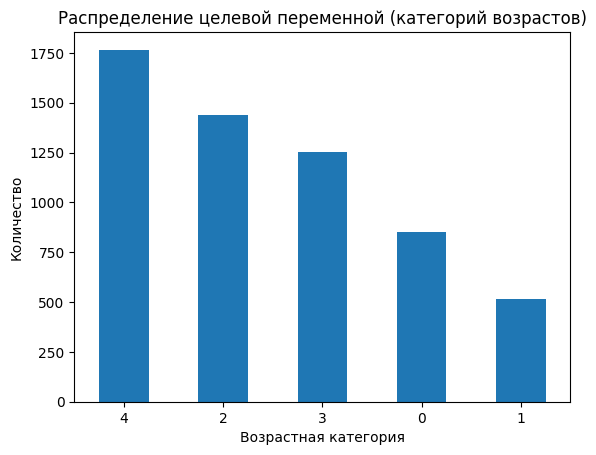

In [13]:
# Визуализируем распределение классов
df['age_category'].value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной (категорий возрастов)')
plt.xlabel('Возрастная категория')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

- Возрастные категории распределены неравномерно:
    - 0 (младше 18): 853 (14.64%)
    - 1 (18-25 лет): 514 (8.82%)
    - 2 (26-40 лет): 1439 (24.7%)
    - 3 (41-55 лет): 1254 (21.52%)
    - 4 (56+ лет): 1756 (30.14%)
    

- Классы несбаланисированы, это стоит учитывать при разделении данных на выборки и построении моделей.

**2.3. Анализ признаков**

- В данных содержится технический признак `user_id` - это уникальный идетнтификатор пользователя (технический признак, который можно удалить, он не нужен для обучения модели)
- Признаки `вечер`, `день`, `ночь`, `утро` содержат информацию о количестве пользовательских сессий в зависимости от времени суток.
- Признаки `category_*` сколько раз пользователь посещал определенную категорию сайтов
- Признаки `days_online`, `sessions_count`, `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage` сфокусированы на особенностях поведения пользователя в сети.

In [14]:
# Удаляем 'user_id'
df.drop(columns='user_id', inplace=True)

In [15]:
# Выведем типы данных признаков (кроме целевой переменной)
df.drop(columns='age_category').dtypes

вечер              int64
день               int64
ночь               int64
утро               int64
category_01        int64
category_02        int64
category_03        int64
category_04        int64
category_05        int64
category_06        int64
category_07        int64
category_08        int64
category_09        int64
category_10        int64
category_11        int64
category_12        int64
category_13        int64
category_14        int64
category_15        int64
category_16        int64
category_17        int64
category_18        int64
category_19        int64
category_20        int64
days_online        int64
sessions_count     int64
ads_activity         str
surf_depth           str
primary_device       str
cloud_usage       object
dtype: object

- Видим, что все числовые признаки представлены типом данных `int64`, категориальные типом `str`, а бинарный признак `cloud_usage` - `object`. Это удобно для дальнейшего разделения признаков, для чего далее мы создадим простую функцию.
- Для числовых признаков мы в дальнейшем будем использовать нормализацию, бинарный признак оставим без изменений.

In [16]:
# Функция для разделения признаков в зависимости от типов данных
def split_features(df):
   
    numeric_features = []
    categorical_features = []
    binary_features = []
    
    for col in df.columns:
        dtype = df[col].dtype
        if dtype == 'int64' or dtype == 'float64':
            numeric_features.append(col)
        elif dtype == 'str':
            categorical_features.append(col)
        else:
            binary_features.append(col)
    
    return numeric_features, categorical_features, binary_features

In [17]:
# Разделяем признаки и проверяем результат работы функции
numeric_features, categorical_features, binary_features = split_features(df.drop(columns='age_category')) 

print('Числовые признаки')
print(numeric_features)
print('-'*50)
print('Категориальные признаки')
print(categorical_features)
print('-'*50)
print('Бинарные признаки')
print(binary_features)

Числовые признаки
['вечер', 'день', 'ночь', 'утро', 'category_01', 'category_02', 'category_03', 'category_04', 'category_05', 'category_06', 'category_07', 'category_08', 'category_09', 'category_10', 'category_11', 'category_12', 'category_13', 'category_14', 'category_15', 'category_16', 'category_17', 'category_18', 'category_19', 'category_20', 'days_online', 'sessions_count']
--------------------------------------------------
Категориальные признаки
['ads_activity', 'surf_depth', 'primary_device']
--------------------------------------------------
Бинарные признаки
['cloud_usage']


- Категориальные признаки содержат небольшое количество уникальных значений, на этапе предобработки подойдет метод OneHotEncoding.

**2.4. Анализ пропущенных значений и дубликатов**

In [18]:
# Найдем пропуски в данных
df.isna().sum()

age_category        0
вечер               0
день                0
ночь                0
утро                0
category_01         0
category_02         0
category_03         0
category_04         0
category_05         0
category_06         0
category_07         0
category_08         0
category_09         0
category_10         0
category_11         0
category_12         0
category_13         0
category_14         0
category_15         0
category_16         0
category_17         0
category_18         0
category_19         0
category_20         0
days_online         0
sessions_count      0
ads_activity      233
surf_depth        111
primary_device    157
cloud_usage       146
dtype: int64

- Пропуски присутствуют во всех трех категориальных признаках. Стратегия: для каждого из них ввести новую категорию «нет данных».

- Пропуски также имеются в бинарном признаке. Оптимальное решение — заменить их на False.

- В числовых данных пропуски отсутствуют.

- Обработка пропусков будет выполнена на этапе предобработки данных.

In [19]:
# Проверим наличие полных дубликатов
df.duplicated().sum()

np.int64(0)

- Полные дубликаты отсутствуют.

**2.5. Анализ числовых признаков**

In [20]:
# Выводим статистистики по числовым признакам
df[numeric_features].describe()

,вечер,день,ночь,утро,category_01,category_02,category_03,category_04,category_05,category_06,...,category_13,category_14,category_15,category_16,category_17,category_18,category_19,category_20,days_online,sessions_count
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,...,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,64.623241,65.796087,14.044456,35.761929,8.994336,7.521799,11.865602,8.766220,10.250601,9.653793,...,11.611226,7.814109,8.833162,7.841572,8.432887,8.639890,9.366289,8.654137,13.998627,180.225712
std,28.648259,28.448239,7.190617,16.175713,7.041371,6.333909,11.189463,6.285614,6.876322,6.531465,...,11.771227,6.534736,6.540778,6.386987,6.500687,6.971413,6.639075,6.606748,0.037034,75.186802
min,22.000000,22.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,100.000000
25%,44.000000,46.000000,9.000000,25.000000,4.000000,3.000000,3.000000,4.000000,6.000000,5.000000,...,1.000000,3.000000,4.000000,3.000000,4.000000,4.000000,5.000000,4.000000,14.000000,124.000000
50%,59.000000,60.000000,13.000000,33.000000,8.000000,6.000000,10.000000,8.000000,9.000000,8.000000,...,9.000000,7.000000,8.000000,7.000000,7.000000,7.000000,8.000000,7.000000,14.000000,167.000000
75%,78.000000,79.000000,17.000000,43.000000,12.000000,11.000000,17.000000,12.000000,14.000000,13.000000,...,18.000000,11.000000,12.000000,11.000000,11.000000,12.000000,13.000000,12.000000,14.000000,213.000000
max,300.000000,305.000000,65.000000,193.000000,79.000000,72.000000,142.000000,74.000000,74.000000,75.000000,...,87.000000,67.000000,57.000000,69.000000,97.000000,68.000000,65.000000,85.000000,14.000000,839.000000


- Анализ статистик указывает на возможное наличие выбросов в большинстве числовых признаков. Для более детального исследования визуализируем выбросы на графиках по каждому признаку.

In [21]:
def plot_reviewers_template(df, feature, target, figsize=(6, 8)):
    """
    1. Scatter plot (признак vs таргет)
    2. Histplot (распределение признака)
    3. Boxplot (ящик с усами)
    """
    
    # Создаем фигуру с 3 строками, 1 колонкой
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, 
        figsize=figsize,
        gridspec_kw={'height_ratios': [3, 2, 0.8]},
        sharex=True
    )
    
    # Данные без пропусков
    data = df[[feature, target]].dropna()
    x_data = data[feature]
    y_data = data[target]
    
    # 1. Распределение относительно целевой переменной
    ax1.scatter(x_data, y_data, alpha=0.6, s=15, color='steelblue', edgecolors='none')
    ax1.set_ylabel('Категория', fontsize=10)
    ax1.set_title(f'{feature}', fontsize=14)  # В заголовке оставляем feature
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # 2. Гистограмма с KDE
    sns.histplot(x_data, ax=ax2, kde=True, color='steelblue', alpha=0.6, edgecolor='white', linewidth=0.5)
    ax2.set_ylabel('Число пользователей', fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    # Добавляем вертикальные линии для среднего и медианы
    mean_val = x_data.mean()
    median_val = x_data.median()
    ax2.axvline(mean_val, color='red', linestyle='-', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax2.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    ax2.legend(fontsize=9)
    
    # 3. Горизонтальный боксплот
    sns.boxplot(x=x_data, ax=ax3, color='steelblue', width=0.5, fliersize=2, linewidth=1)
    ax3.set_xlabel('Число событий', fontsize=10)  
    ax3.set_yticks([])
    ax3.spines['left'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.spines['top'].set_visible(False)
    ax3.grid(True, axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    
    return fig

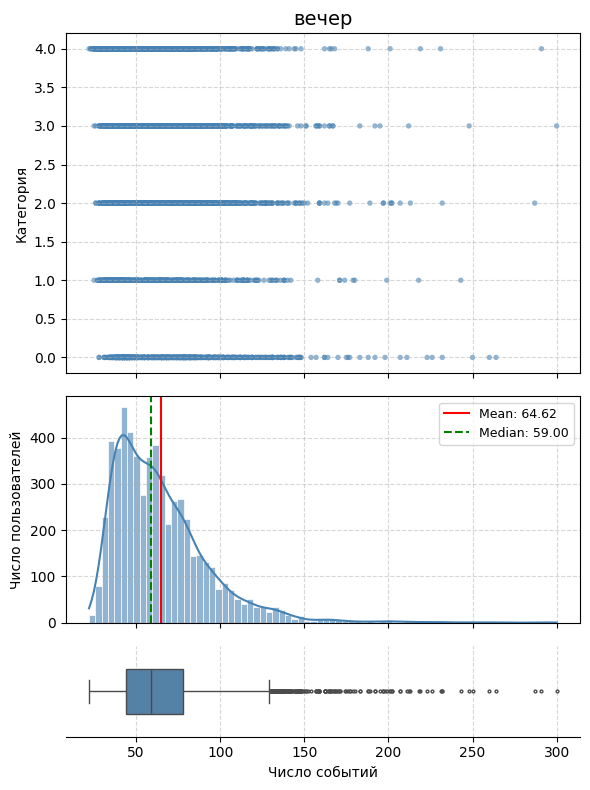

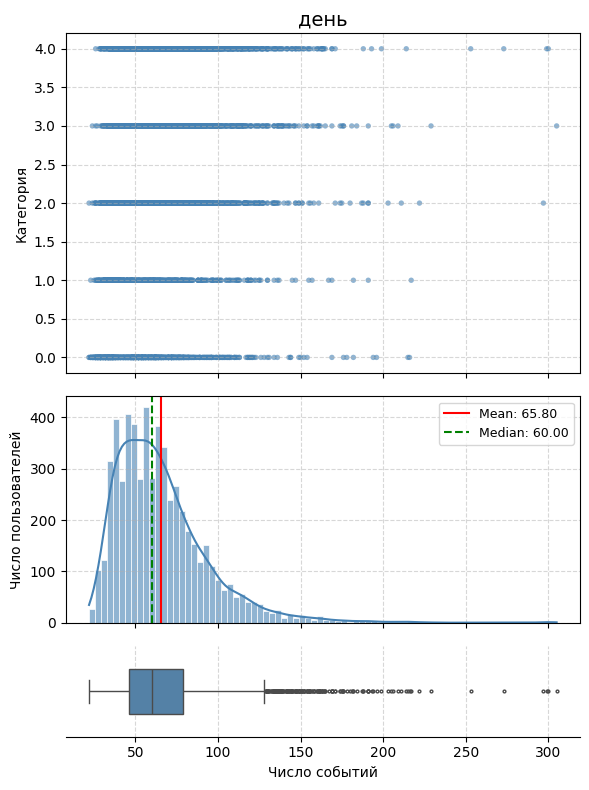

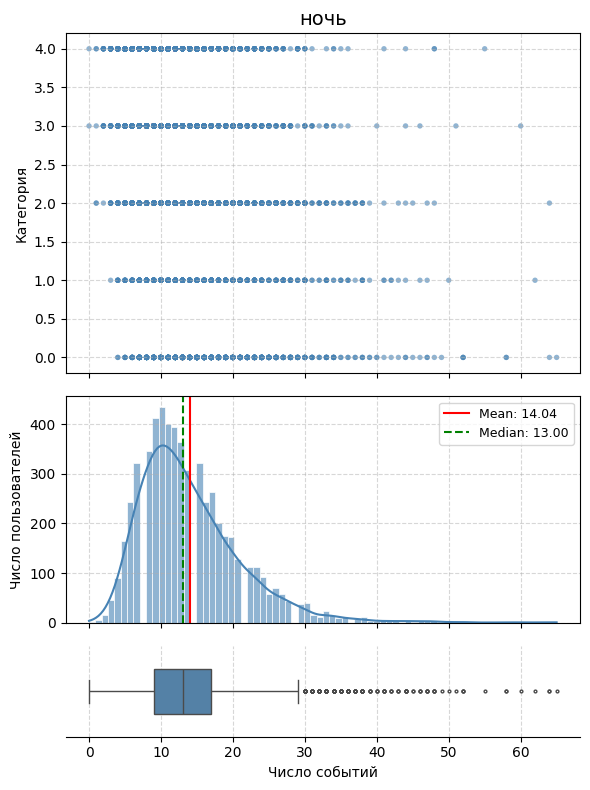

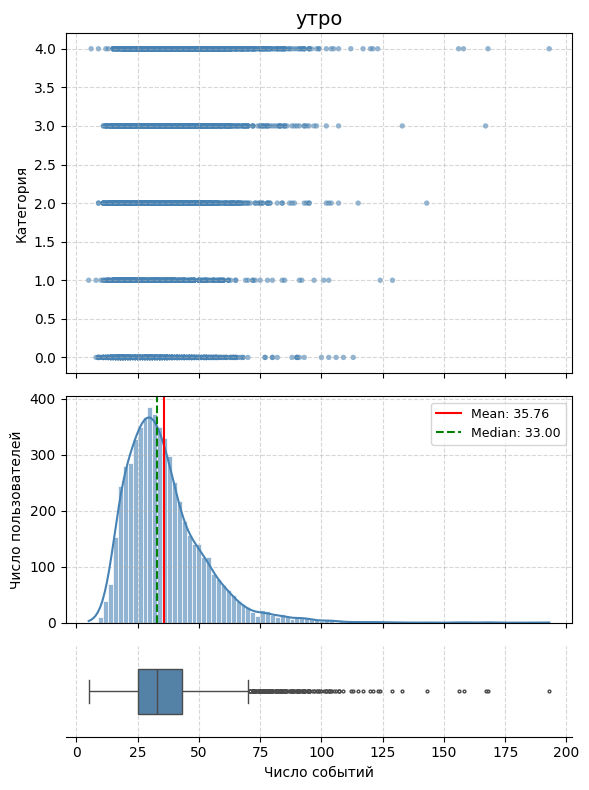

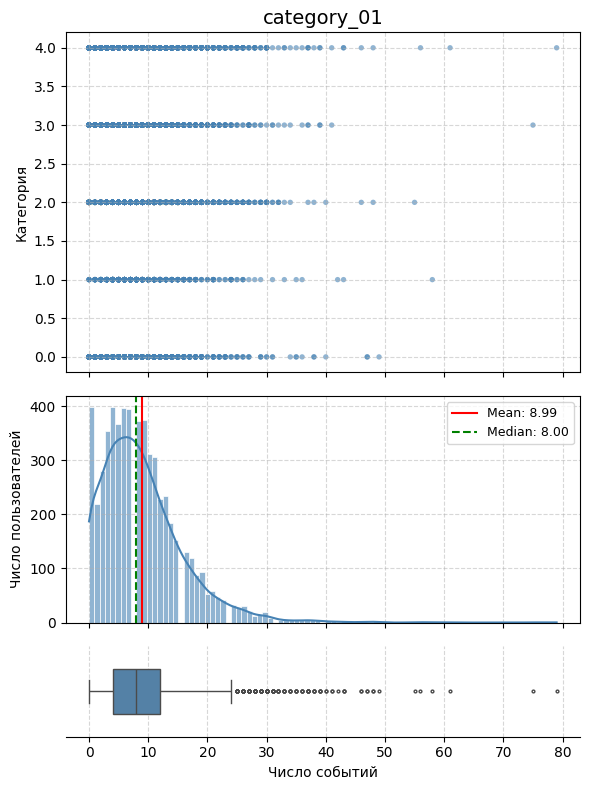

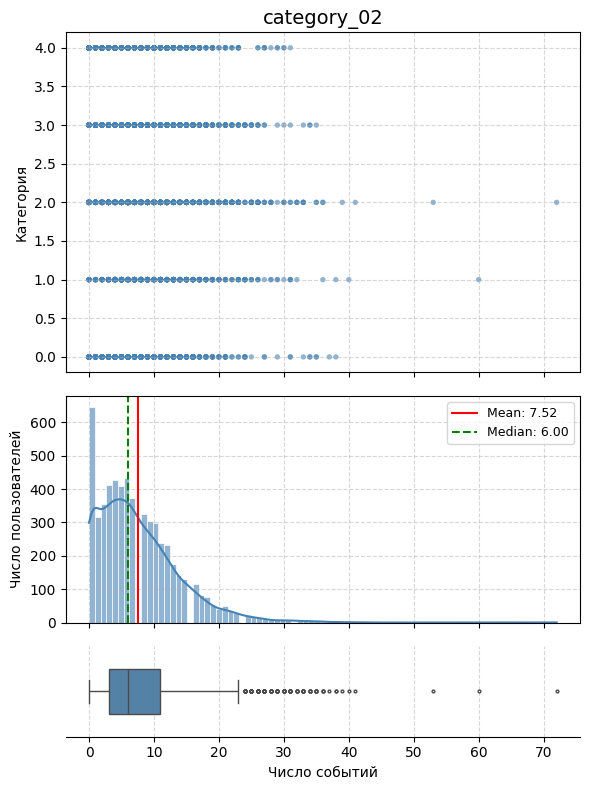

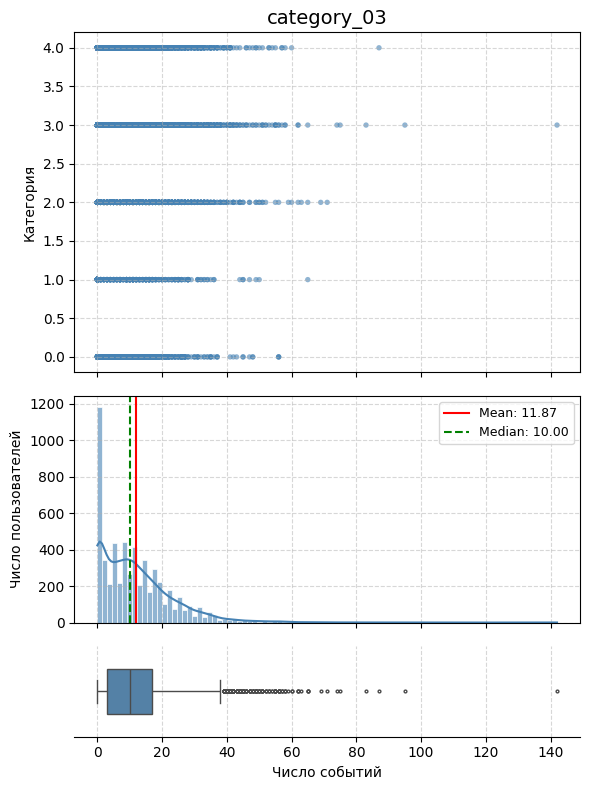

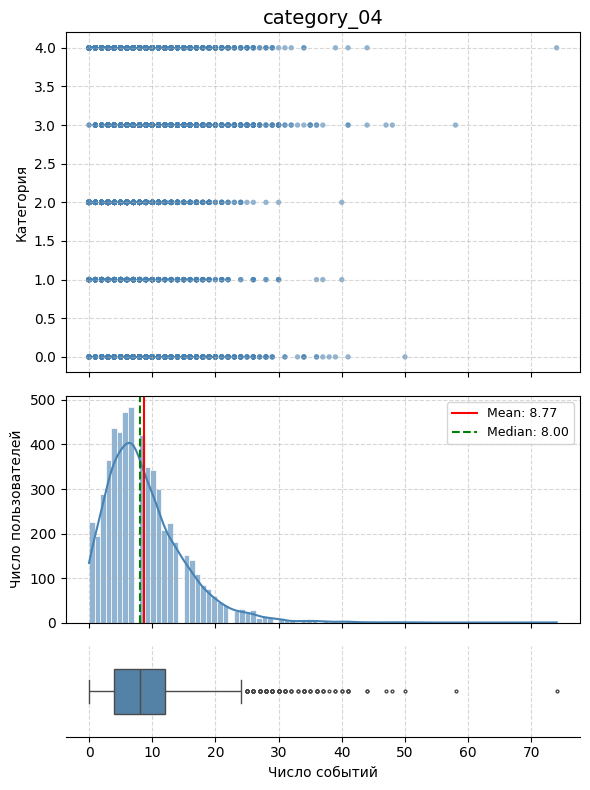

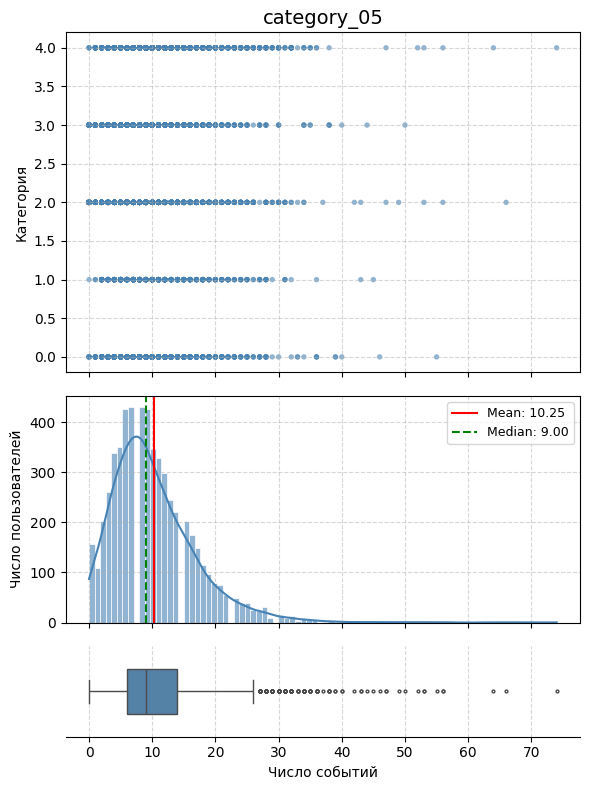

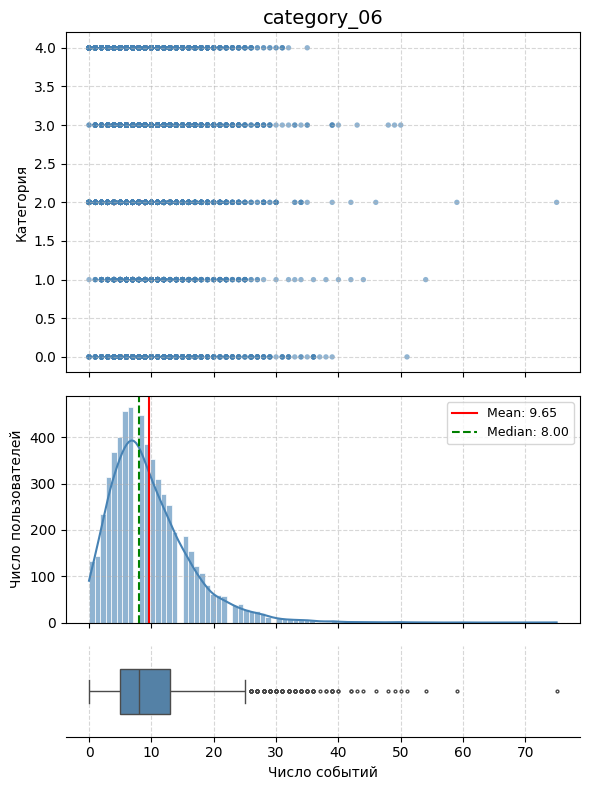

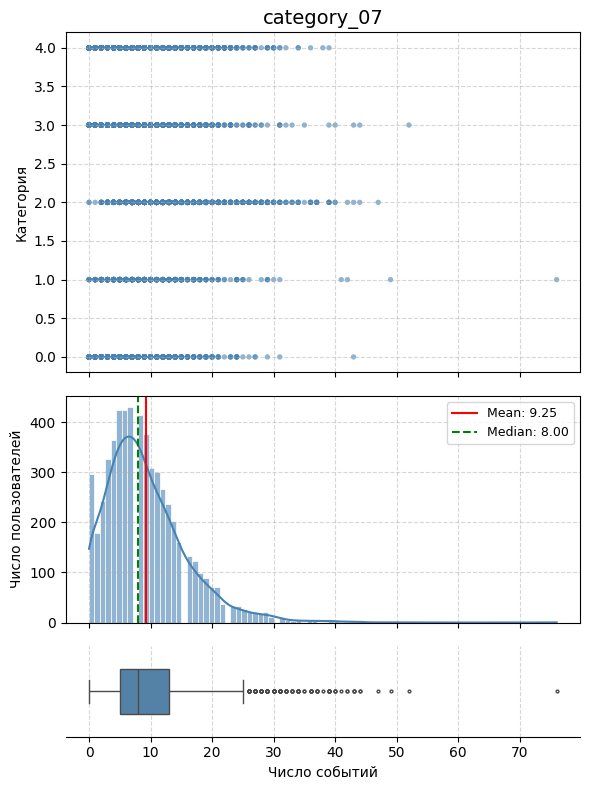

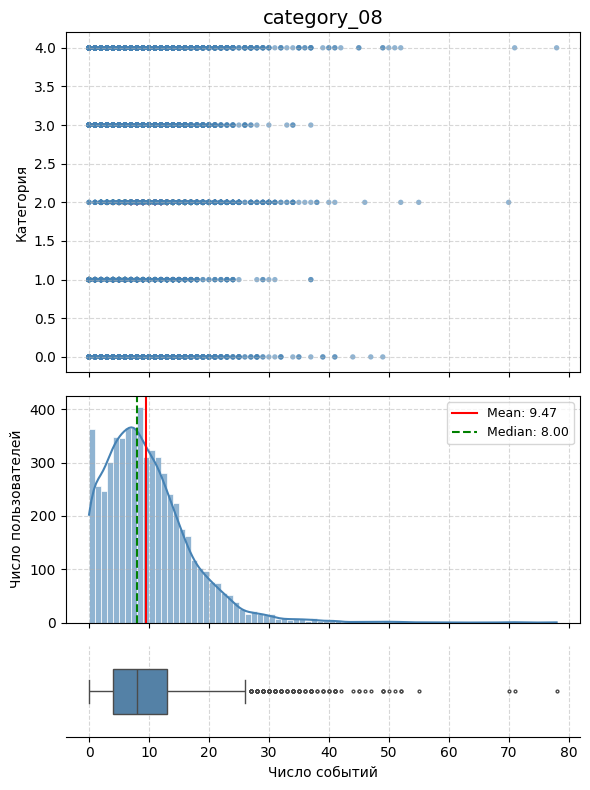

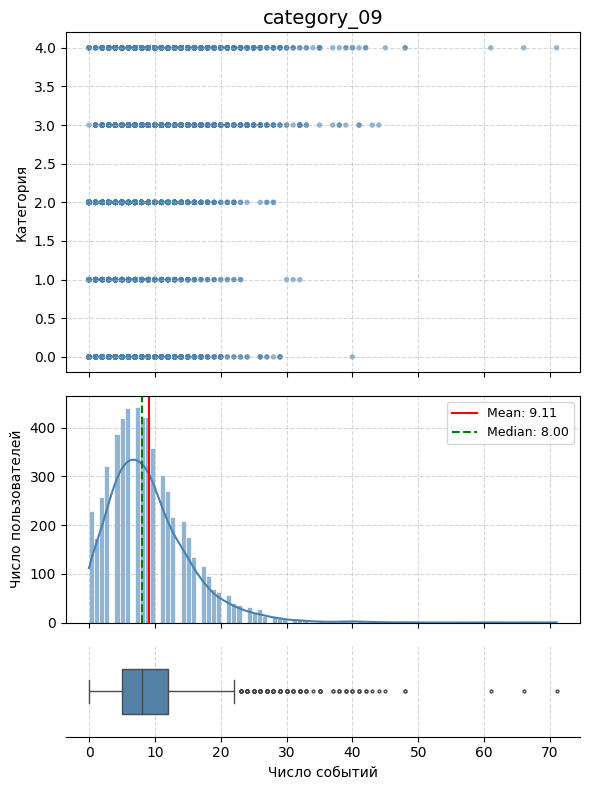

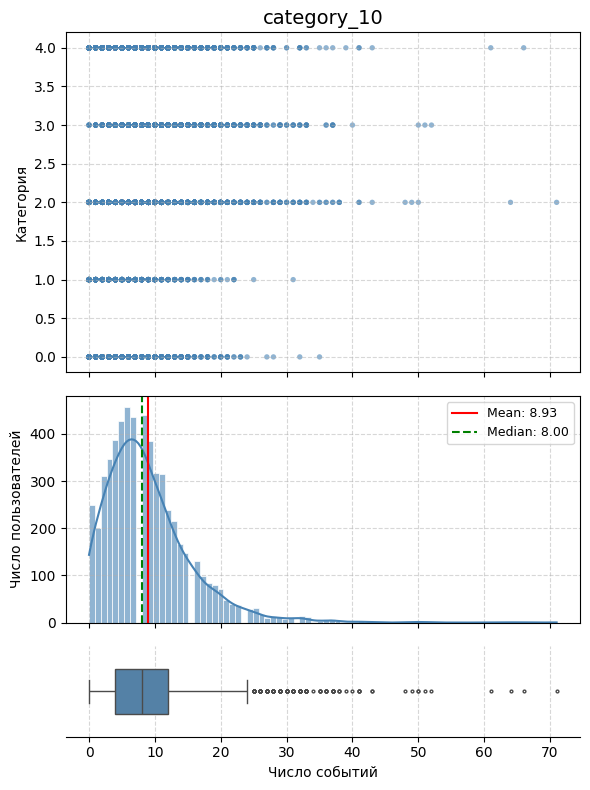

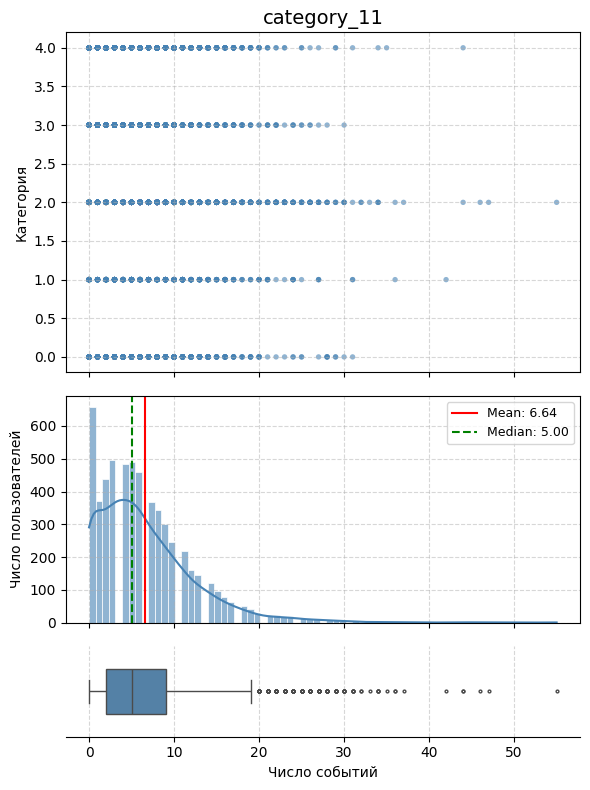

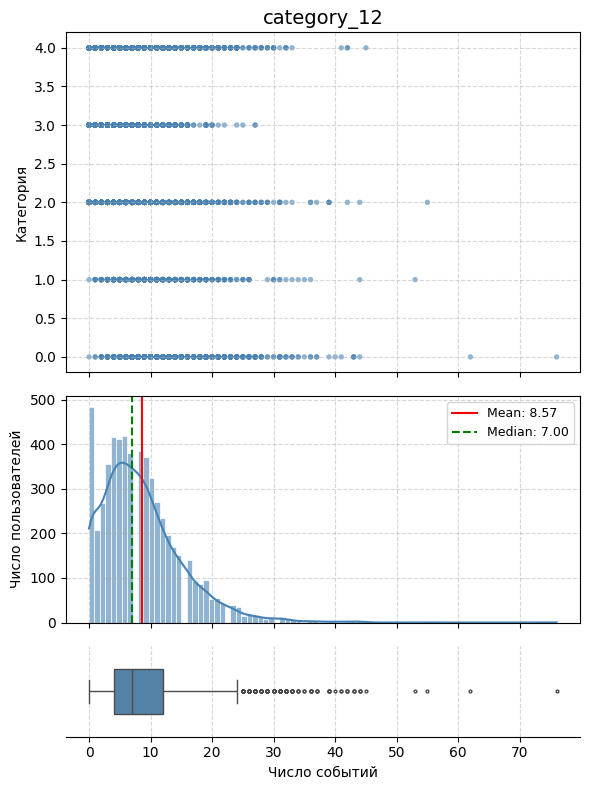

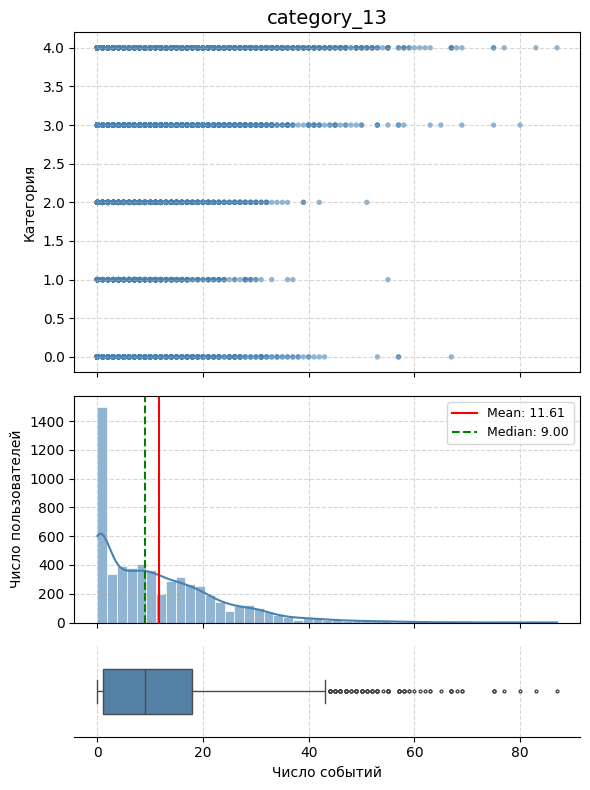

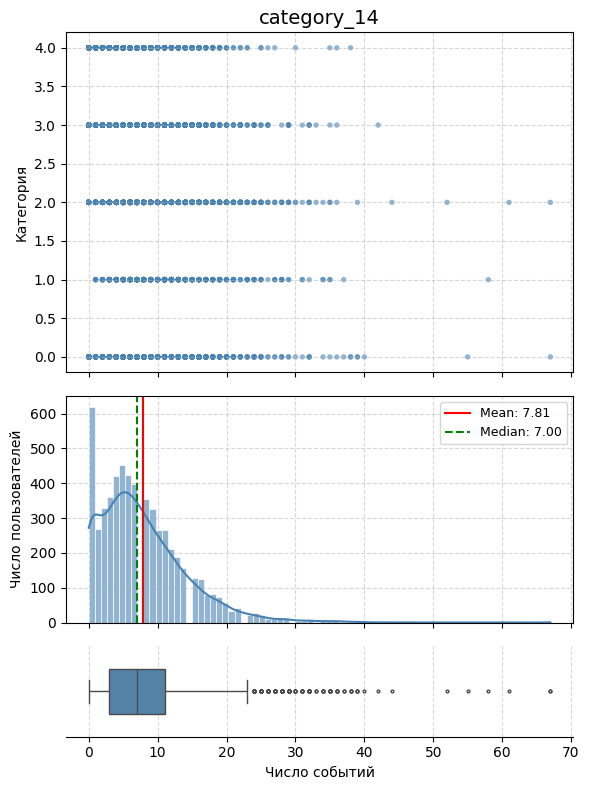

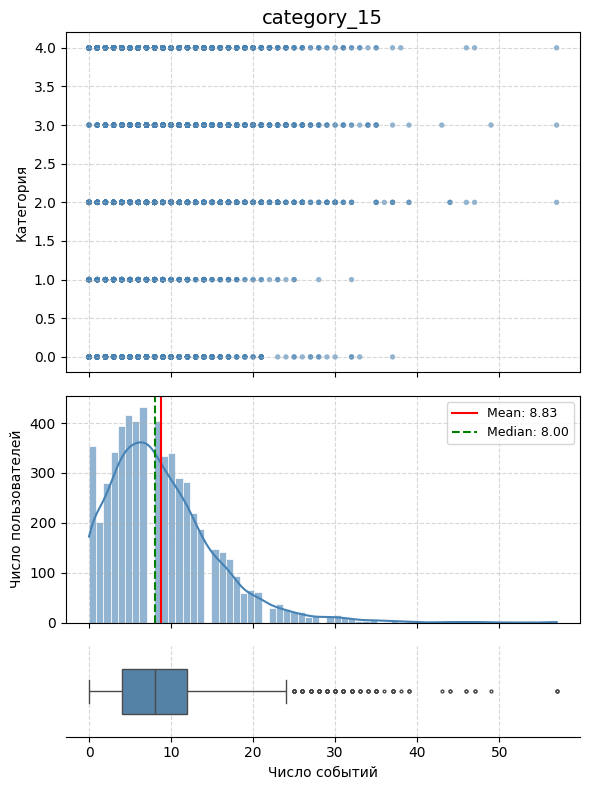

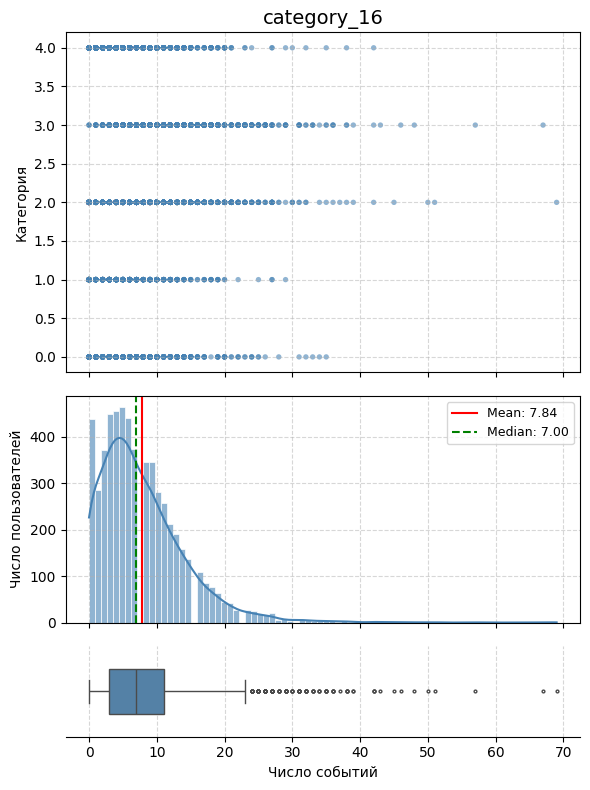

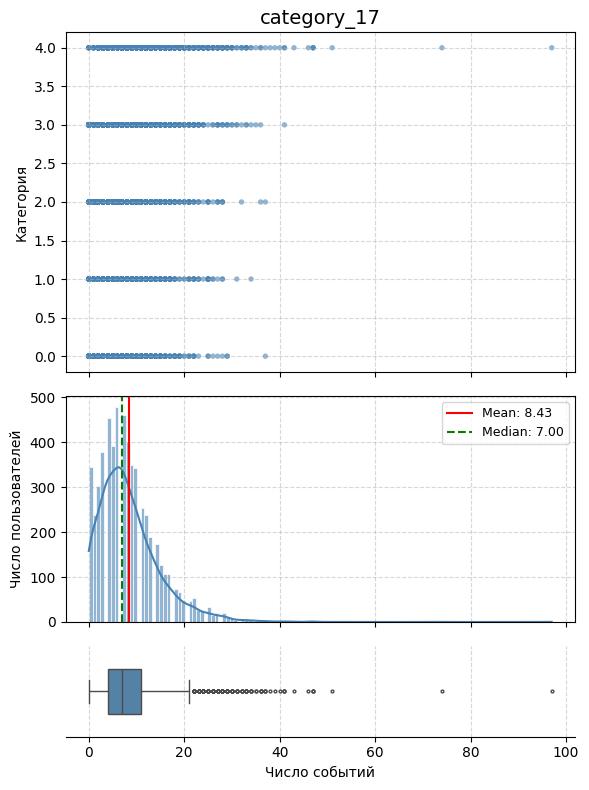

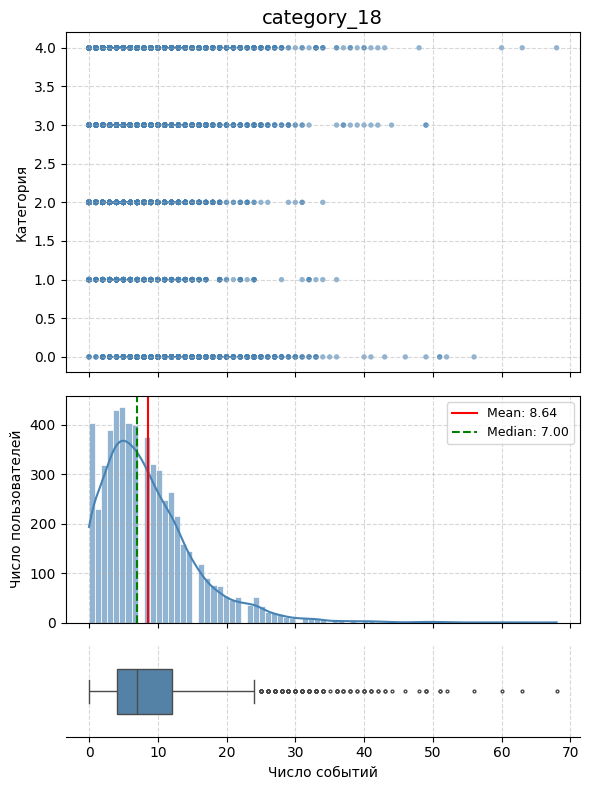

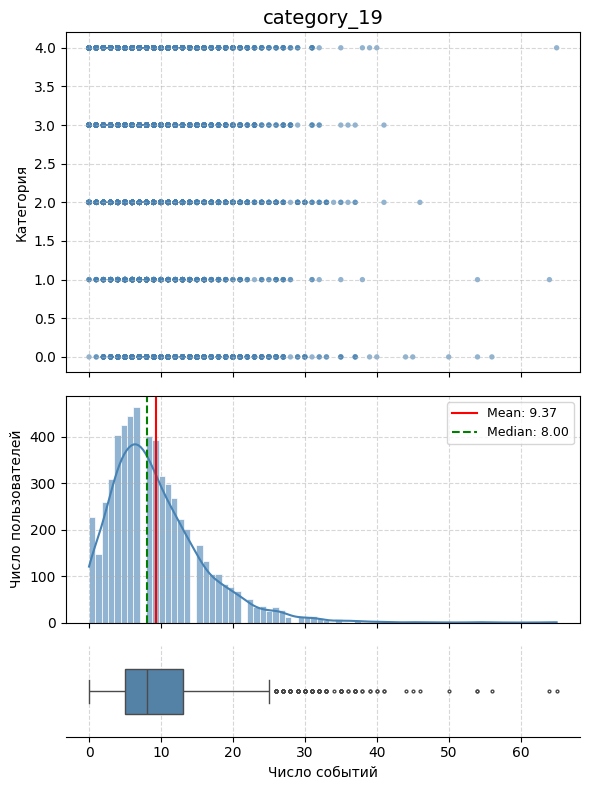

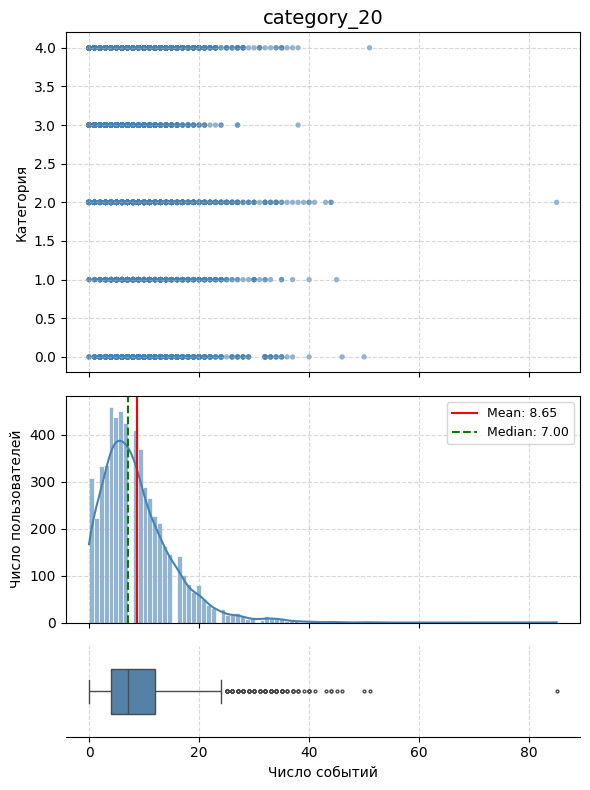

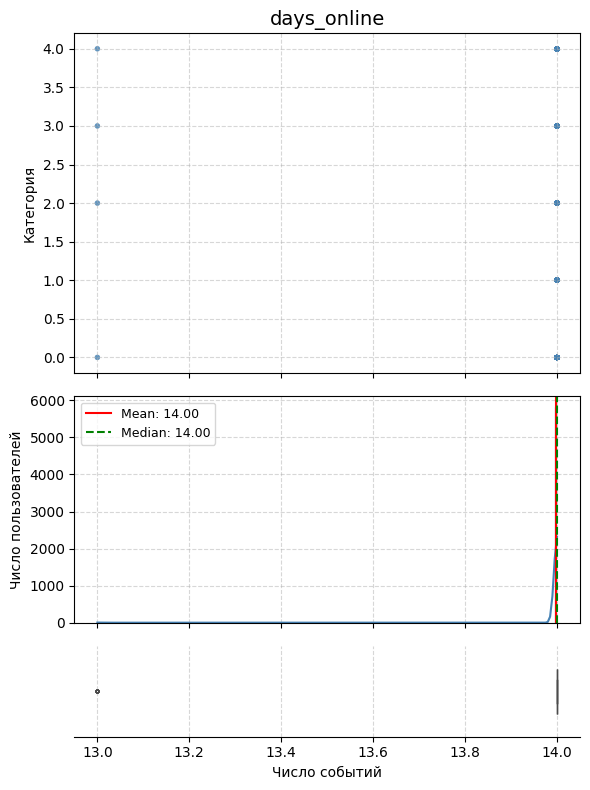

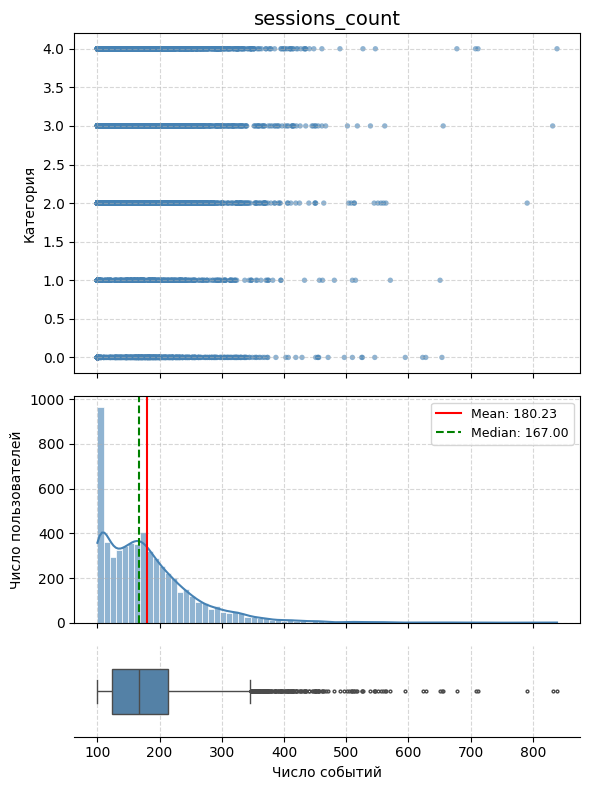

In [22]:
# Запускаем цикл для всех числовых признаков
for fig in df[numeric_features]:
    fig = plot_reviewers_template(df, fig, 'age_category')
    plt.show()

— Выбросы присутствуют у всех признаков, кроме `days_online` (данные по всем пользователям представлены только за 13 либо 14 дней). Выбросы распределены несимметрично, наблюдаются тяжелые правые хвосты — для подобных данных это нормально. На этапе предобработки подойдет `RobustScaler()`, так как он использует межквартильный размах и лучше справляется с выбросами.

**2.6. Анализ категориальных признаков**

In [23]:
# Смотрим количество уникальных значений для категориальных признаков
for col in df[categorical_features].columns:
    unique_values = df[col].nunique()
    print(f'Колонка: {col}')
    print('', unique_values)
    print('-'*50)

Колонка: ads_activity
 5
--------------------------------------------------
Колонка: surf_depth
 3
--------------------------------------------------
Колонка: primary_device
 4
--------------------------------------------------


- Категориальные признаки имеют низкую кардинальность, значит на этапе предобработки будем использовать `OnehotEncoder`.

**2.7. Анализ корреляций**

- Так как данные содержат числовые, категориальные и бинарные признаки, оптимальным решением будет построение корреляционной матрицы с использованием универсального метода `phik`.

In [24]:
# Готовим список для корреляционной матрицы
interval_columns = numeric_features.copy()

In [25]:
# Смотрим уникальные значения
df[interval_columns].nunique()

вечер             178
день              177
ночь               59
утро              119
category_01        54
category_02        45
category_03        72
category_04        48
category_05        56
category_06        52
category_07        49
category_08        55
category_09        49
category_10        52
category_11        43
category_12        49
category_13        72
category_14        48
category_15        46
category_16        50
category_17        48
category_18        54
category_19        50
category_20        49
days_online         2
sessions_count    366
dtype: int64

In [26]:
interval_columns.remove('days_online') # убираем из списка, так как всего два уникальных значения

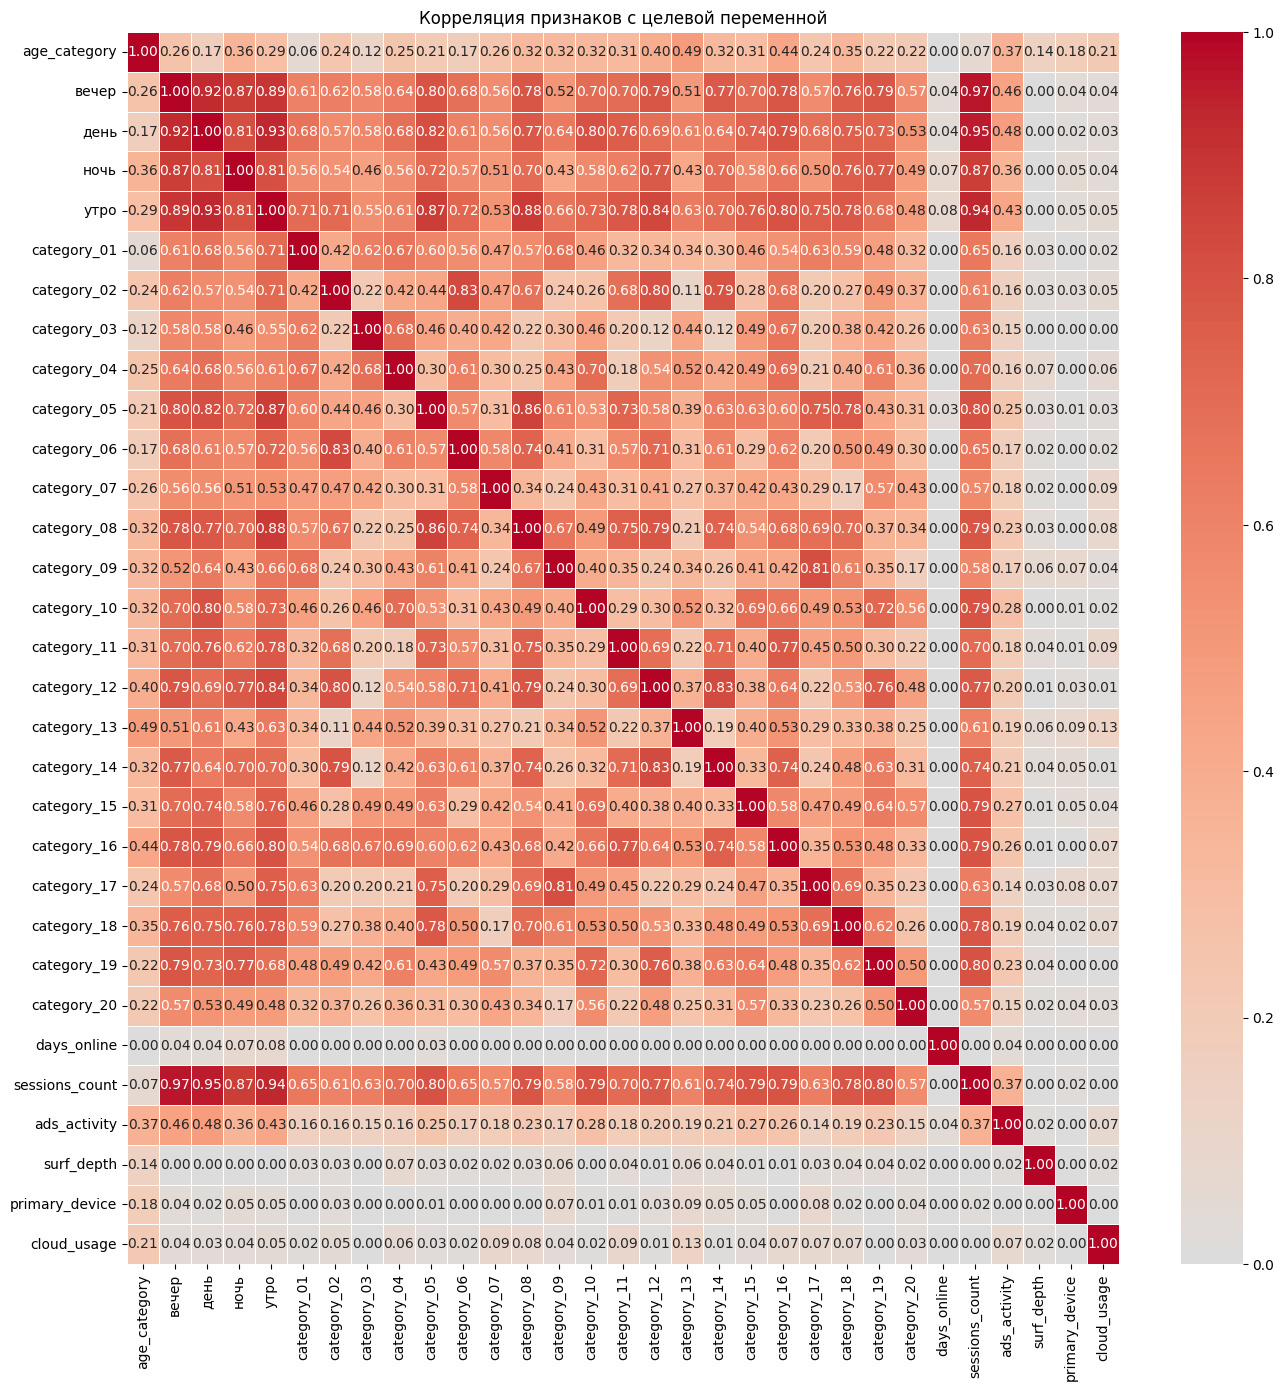

In [27]:
corr_matrix = df.phik_matrix(interval_cols=interval_columns)

plt.figure(figsize=(16,16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt='.2f')
plt.title('Корреляция признаков с целевой переменной')
plt.show()

- Наибольшую связь с целевой переменной показывают признаки `category_13`, `category_16`, `category_12` (0.40–0.49).


- Почти все признаки имеют слабую или умеренную связь с целевой переменной.


- Нулевую связь имеет признак `days_online`. Как уже было установлено, он принимает всего два значения: 13 или 14 дней. Сам по себе он не нужен, но пригодится для создания новых признаков — например, среднего числа сессий в день (`sessions_count` / `days_online`).


- Высокая мультиколлинеарность наблюдается между признаками `утро`, `день`, `вечер`, `ночь` и `sessions_count` (0.87–0.97).


- Умеренная и высокая мультиколлинеарность также присутствует между многими категориями сайтов.


- Учитывая мультиколлинеарность между многими признаками при том, что в основном они могут быть важны для обучения модели, следует рассмотреть возможность генерации новых признаков и замены части существующих.

На основе анализа корреляционной матрицы сформулируем несколько гипотез для генерации признаков:

- Категории сайтов:

    - Самая популярная категория сайта для каждого пользователя (предпочтения могут меняться в зависимости от возраста).

    - Количество уникальных категорий с ненулевой активностью .


- Время суток:

    - Пиковое время суток (распределение может различаться в зависимости от возраста).

    - Энтропия распределения (равномерность активности)
    
    - Среднее количество сессий в день (общее представление о том, сколько времени пользователь проводит в сети).

    - Среднее число событий за день`.

    - Доля активности в зависимости от времени суток.



**2.8. Общие выводы по EDA**

**1. Структура данных**
- Датасет содержит 5826 уникальных пользователей, 32 признака (после удаления `user_id` — 31).
- Целевая переменная — `age_category` (5 классов: 0–4).

**2. Целевая переменная**
- Классы несбалансированы: наибольший — класс 4 (56+ лет, 30.1%), наименьший — класс 1 (18–25 лет, 8.8%).
- При разбиении выборок необходима **стратификация** по `age_category`.

**3. Качество данных**
- Полные дубликаты отсутствуют.
- Присутствуют пропуски: `ads_activity` (233), `surf_depth` (111), `primary_device` (157), `cloud_usage` (146).
- **Стратегия обработки пропусков:**
  - Категориальные признаки → новая категория `"unknown"`.
  - Бинарный признак `cloud_usage` → заполнение `False`.

**4. Числовые признаки (26 шт.)**
- Выбросы присутствуют, распределения асимметричны (тяжёлые правые хвосты).
- `days_online` принимает только 2 значения (13 или 14), корреляция с целевой переменной равна 0.
- **Стратегия обработки:** `RobustScaler()` (устойчив к выбросам).

**5. Категориальные признаки**
- `ads_activity` (5 категорий), `surf_depth` (3 категории), `primary_device` (4 категории).
- Низкая кардинальность → **OneHotEncoder**.

**6. Бинарный признак**
- `cloud_usage` (True/False + пропуски) — будет закодирован отдельно.

**7. Корреляционный анализ (phik)**
- Наибольшая связь с возрастом: `category_13`, `category_16`, `category_12` (0.40–0.49).
- Высокая мультиколлинеарность между `утро/день/вечер/ночь` и `sessions_count` (0.87–0.97).
- Мультиколлинеарность также присутствует между категориями сайтов.

**8. Дальнейшие шаги**
- Удаление технических и низкоинформативных признаков (`days_online`), а также создание новых признаков (доли времени суток, средние сессии в день, энтропия, топ-категории) будет выполнено **после обучения базовой модели** на этапе отбора и генерации признаков.
- Базовую модель обучим на текущих признаках с минимальной предобработкой (масштабирование, OHE, заполнение пропусков).

## 3. Разделение данных на выборки

- Мы имеем сравнительно небольшое количество данных (5826 наблюдений), поэтому для экономии мы будем использовать только тренировочную и тестовую выборку и применять стратификацию для подбора гиперпараметров.

In [28]:
# Отделим признаки и целевую переменную
X = df.drop(columns='age_category')
y = df['age_category']

# Стратифицированное разделение на Train и Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Набор данных | Размер | Цель")
print("-" * 40)
print(f"Тренировочный (Train) | {len(X_train)} | Обучение базовой модели")
print(f"Тестовый (Test)       | {len(X_test)}  | Финальная оценка")
print("-" * 40)
print(f"Сумма: {len(X_train) + len(X_test)}")

Набор данных | Размер | Цель
----------------------------------------
Тренировочный (Train) | 4660 | Обучение базовой модели
Тестовый (Test)       | 1166  | Финальная оценка
----------------------------------------
Сумма: 5826


- Данные разделены стратифицированно, с учетом дисбаланса классов.
- Тестовая выборка составляет 20% от общего числа данных.

## 4. Предобработка данных — построение пайплайнов

In [29]:
# Пайплайн для числовых признаков 
numeric_pipeline = Pipeline(steps=[
    ('scaler', RobustScaler())
])

# Пайплайн для категориальных признаков
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='нет данных')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

# Пайплайн для бинарного признака
binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=False))
])

# Препроцессор
preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features),
    ('binary', binary_pipeline, binary_features)
])

- Данные подготовлены для предобработки, можно приступать к обучению моделей.

## 5. Обучение и оценка базовой модели

- В качестве базовой модели машинного обучения мы посторим дамми-модель: результаты ее работу будут примерно соответствовать случайному угадыванию.

In [30]:
# Подготовим функцию для выведения необходимых метрик
def print_metrics(result):

    f1_macro = round(result['test_f1_macro'].mean(), 3)
    precision_macro = round(result['test_precision_macro'].mean(), 3)
    recall_macro = round(result['test_recall_macro'].mean(), 3)

    print(f'f1_score_macro: {f1_macro}')
    print(f'precision_macro: {precision_macro}')
    print(f'recall_macro: {recall_macro}')

    return f1_macro, precision_macro, recall_macro

In [31]:
# Необходимые метрики согласно поставленной задачи
metrics = ['f1_macro', 'precision_macro', 'recall_macro']

# Стратификация с учетом дисбаланса классов для кросс-валидации
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# Обучаем базовую дамми-модель
dummy_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(random_state=RANDOM_STATE))
])

dummy_result = cross_validate(dummy_model, X_train, y_train, cv=skf, scoring=metrics, n_jobs=-1)

dummy_f1, dummy_precision, dummy_recall = print_metrics(dummy_result)

f1_score_macro: 0.093
precision_macro: 0.061
recall_macro: 0.2


- `macro Recall = 0.20` означает, что модель «угадывает» только 1 класс из 5 (класс 4), по остальным классам recall = 0.
- `macro Precision = 0.061` — низкая точность, так как предсказания сконцентрированы в одном классе.
- `macro F1 = 0.093` — гармоническое среднее, ожидаемо низкое.

## 6. Создание и отбор признаков

- Перед началом работы с признаками построим модель логистической регрессии с первоначальным набор признаков. С ней будем сравнивать последующие модели с модифицированными признаками.

In [32]:
lr_base_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(solver='lbfgs', class_weight='balanced', random_state=RANDOM_STATE))
])

lr_base_result = cross_validate(lr_base_model, X_train, y_train, cv=skf, scoring=metrics, n_jobs=-1)

lr_base_f1, lr_base_precision, lr_base_recall = print_metrics(lr_base_result)

f1_score_macro: 0.814
precision_macro: 0.809
recall_macro: 0.824


In [33]:
# Создаем копию датасета 
df_modified = df.copy()

- Проверяем гипотезы по генерации признаков, сформулированные на этапе EDA

In [34]:
# Узнаем самую популярную категорию сайтов
cat_cols = [col for col in df_modified.columns if col.startswith('category_')]
df_modified['top_category'] = df_modified[cat_cols].idxmax(axis=1)

# Считаем количество категорий с ненулевой активностью
positive_mask = df_modified[cat_cols] > 0
df_modified['nonzero_cat_count'] = positive_mask.sum(axis=1)

# Среднее количество событий в сутки
df_modified['avg_sessions_per_day'] = df_modified['sessions_count'] / df_modified['days_online']

# Среднее количество событий в зависимости от времени суток
df_modified['morning_pct'] = df_modified['утро'] / df_modified['sessions_count']
df_modified['day_pct'] = df_modified['день'] / df_modified['sessions_count']
df_modified['evening_pct'] = df_modified['вечер'] / df_modified['sessions_count']
df_modified['night_pct'] = df_modified['ночь'] / df_modified['sessions_count']

# Пиковое время активности
df_modified['peak_time'] = df[['утро', 'день', 'вечер', 'ночь']].idxmax(axis=1)

# Вычисляем энтропию распределения активности по времени суток
def calculate_entropy_vectorized(df, time_cols):
    probs = df[time_cols].values
    # Обрезаем нули
    probs = np.maximum(probs, 1e-10)
    entropy = -np.sum(probs * np.log2(probs), axis=1)
    return entropy

time_cols = ['morning_pct', 'day_pct', 'evening_pct', 'night_pct']
df_modified['activity_entropy'] = calculate_entropy_vectorized(df_modified, time_cols)


In [35]:
# Удаляем признаки с высокой мультиколлинеарностью, которые мы использовали для создания новых признаков
df_modified.drop(columns=['вечер', 'день', 'ночь', 'утро', 'days_online', 'sessions_count'], inplace=True)

- Удаление исходных признаков (`вечер`/`день`/`ночь`/`утро`, `sessions_count`, `days_online`) проведено на основе EDA: высокая мультиколлинеарность между ними. Сгенерированные признаки (доли, энтропия, среднее) сохраняют смысловую нагрузку, но снижают размерность.

In [36]:
# Используем функцию, чтобы отделить численные признаки
interval_columns_mod, _, _ = split_features(df_modified)

In [37]:
# Смотрим уникальные значения
df_modified[interval_columns_mod].nunique()

age_category               5
category_01               54
category_02               45
category_03               72
category_04               48
category_05               56
category_06               52
category_07               49
category_08               55
category_09               49
category_10               52
category_11               43
category_12               49
category_13               72
category_14               48
category_15               46
category_16               50
category_17               48
category_18               54
category_19               50
category_20               49
nonzero_cat_count          6
avg_sessions_per_day     372
morning_pct             2472
day_pct                 2621
evening_pct             2718
night_pct               1926
activity_entropy        5744
dtype: int64

In [38]:
# Удаляем из списка признаки с небольшим числом уникальных значений
interval_columns_mod.remove('age_category')
interval_columns_mod.remove('nonzero_cat_count')

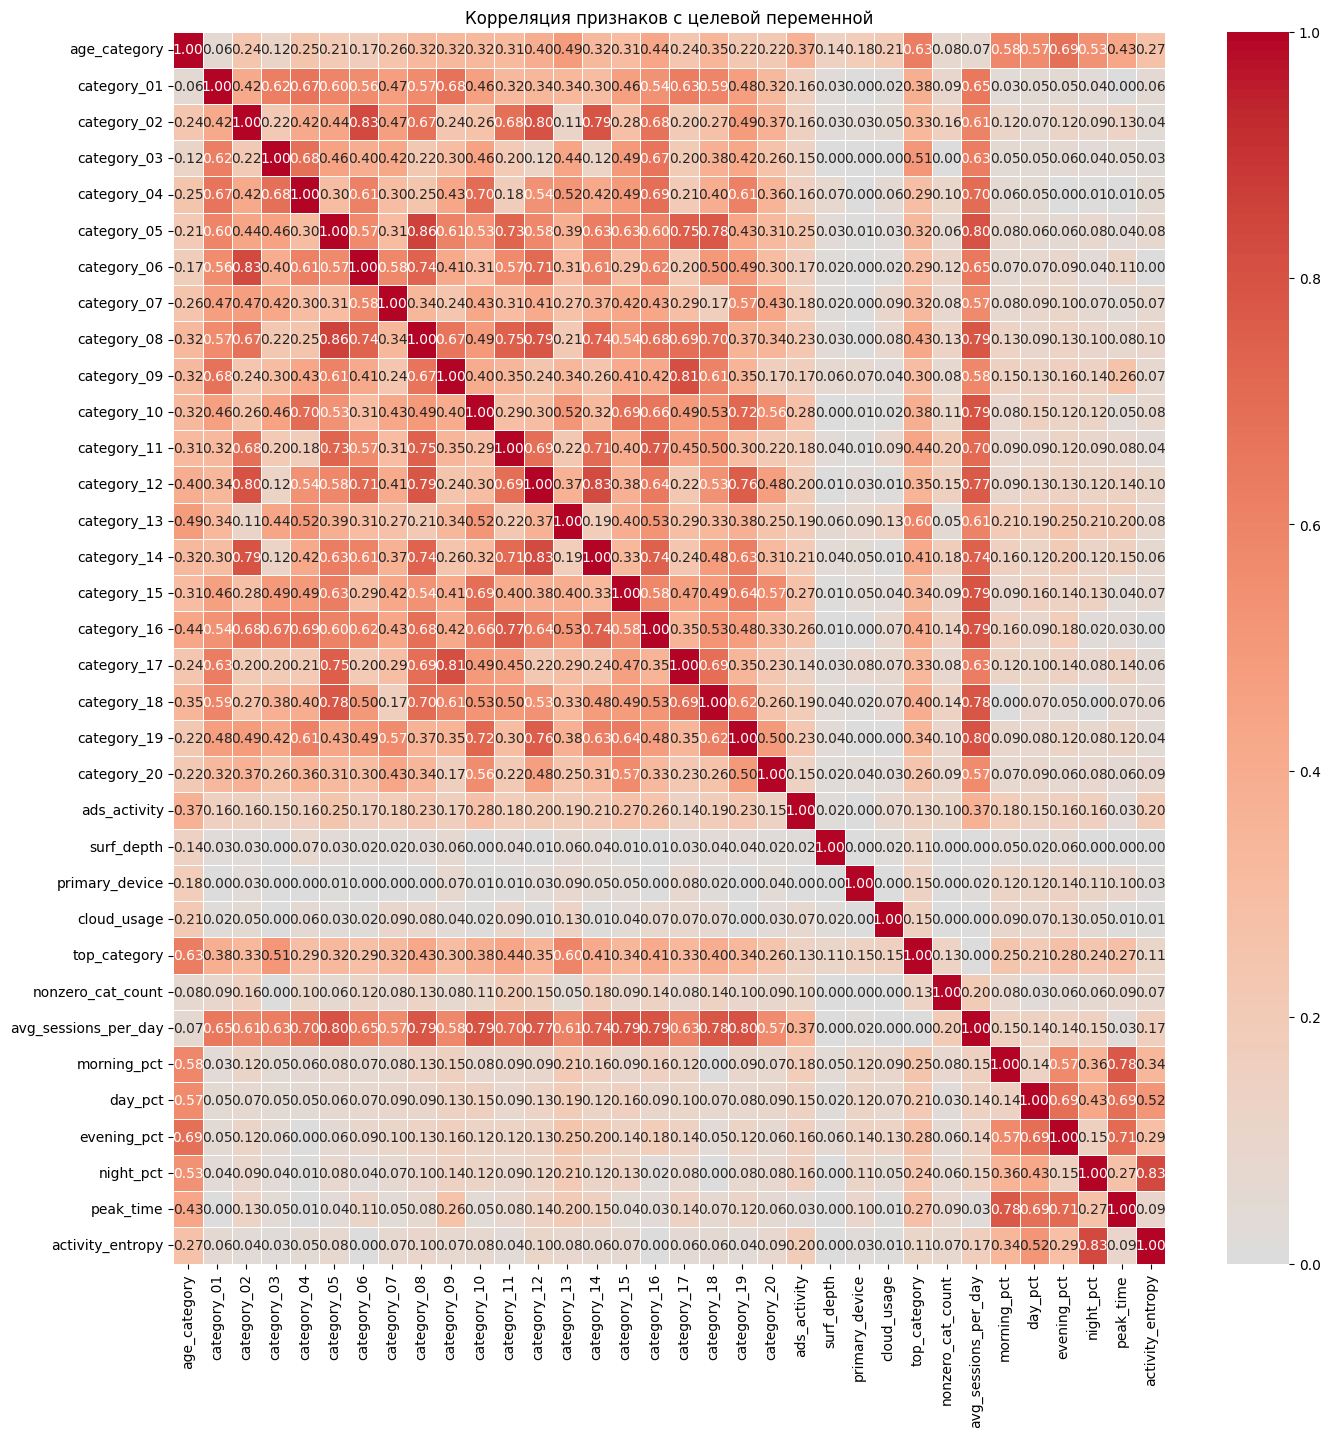

In [39]:
# Визуализируем матрицу корреляций, чтобы ознакомиться с результатом
new_features_matrix = df_modified.phik_matrix(interval_cols = interval_columns_mod)


plt.figure(figsize=(16,16))
sns.heatmap(new_features_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt='.2f')
plt.title('Корреляция признаков с целевой переменной')
plt.show()

- Сгенерированные признаки `nonzero_cat_count`, `avg_sessions_per_day` минимально коррелируют с целевой переменной (0.07-0.08), их мы не будем использовать. Также избавимся от признака с низкой связью `category_01` (0.06).
- Сгенерированные признаки `top_category`, `nonzero_cat_count`, `avg_sessions_per_day`, `morning_pct`, `day_pct`, `evening_pct`, `night_pct`, `peak_time` показывают умеренно высокую связь с целевой переменной (0.43-0.63), они будут полезны для обучения модели.
- Удалось избавится от мультиколлинераности между признаками утро, день, вечер, ночь за счет их преобразования.
- Остается умеренно высокая мультиколлинеарность между различными категориями сайтов. Решение: использование L2 регуляризации для обучения модели.

In [40]:
# Избавляемся от малозначительных признаков
df_modified.drop(columns=['category_01', 'nonzero_cat_count', 'avg_sessions_per_day'], inplace=True)

In [41]:
# Отделим признаки и целевую переменную для модифицированных признаков
X_mod = df_modified.drop(columns='age_category')
y_mod = df_modified['age_category']

# Стратифицированное разделение на Train и Test
X_train_mod, X_test_mod, y_train_mod, y_test_mod = train_test_split(
    X_mod, y_mod, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


In [42]:
# Разделим признаки обновленного для на числовые, категориальные и бинарные
numeric_features_mod, categorical_features_mod, binary_features_mod = split_features(df_modified.drop(columns='age_category'))

In [43]:
# Доработаем препроцессор для новых признаков
preprocessor_modified = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numeric_features_mod),
    ('categorical', categorical_pipeline, categorical_features_mod),
    ('binary', binary_pipeline, binary_features_mod)
])

In [44]:

lr_mod_model = Pipeline(steps=[
    ('preprocessor', preprocessor_modified),
    ('model', LogisticRegression(solver='lbfgs', class_weight='balanced', random_state=RANDOM_STATE))
])

lr_mod_result = cross_validate(lr_mod_model, X_train_mod, y_train_mod, cv=skf, scoring=metrics, n_jobs=-1)

lr_mod_f1, lr_mod_precision, lr_mod_recall = print_metrics(lr_mod_result)

f1_score_macro: 0.814
precision_macro: 0.809
recall_macro: 0.824


- Видим, что модель линейной регрессии на сгенерированных показала себя хуже по сравнению с моделью построенной на первоначальном наборе:
    `f1_score_macro`: 0.79 < 0.814;
    `precision_macro`: 0.784 < 0.809;
    `recall_macro`: 0.801 < 0.824.

- Для отбора гиперпараметров будем использовать исходный набор признаков.
- Общее число признаков не велико, использовать дополнительную фильтрацию не имеет смысла, будет достаточно подобрать оптимальный метод регуляризации.

## 7. Подбор гиперпараметров моделей

- Для подбора оптимальной конфигурации параметров создадим цикл, который будет перебирать элементы словаря параметрических сеток для каждой подходящей модели задачи многоклассовой классификации.
- Также проверим модели SVC, поскольку у признаков могут иметься нелинейные связи.
- Небольшое количество строк (5826) позволит выполнить перебор всех параметров без серьезной вычислительной нагрузки.



In [45]:
param_grid = [
    {
        # Логистическая регрессия
        'name': 'LogisticRegression',
        'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        'param_grid': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__penalty': ['l1', 'l2'],
            'model__solver': ['liblinear', 'saga', 'lbfgs']
        }
    },
    {
        # Логистическая регрессия OvR
        'name': 'LogisticRegression - OneVsRest',
        'model': OneVsRestClassifier(LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
        'param_grid': {
            'model__estimator__C': [0.01, 0.1, 1, 10],
            'model__estimator__penalty': ['l2'], # 'lbfgs' поддерживает только l2 регуляризацию
            'model__estimator__solver': ['lbfgs']
        }
    },
    {
        # Логистическая регрессия OvO
        'name': 'LogisticRegression - OneVsOne',
        'model': OneVsOneClassifier(LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
        'param_grid': {
            'model__estimator__C': [0.01, 0.1, 1, 10],
            'model__estimator__penalty': ['l2'],
            'model__estimator__solver': ['lbfgs']
        }
    },
    {
        # SVC OvR
        'name': 'SVC - OneVsRest',
        'model': OneVsRestClassifier(SVC(random_state=RANDOM_STATE, max_iter=1000)),
        'param_grid': {
            'model__estimator__C': [0.01, 0.1, 1, 10],
            'model__estimator__kernel': ['poly', 'rbf', 'sigmoid'],
            'model__estimator__gamma': ['scale', 'auto']
        }
    },
    {
        # SVC OvO
        'name': 'SVC - OneVsOne',
        'model': OneVsOneClassifier(SVC(random_state=RANDOM_STATE, max_iter=1000)),
        'param_grid': {
            'model__estimator__C': [0.01, 0.1, 1, 10],
            'model__estimator__kernel': ['poly', 'rbf', 'sigmoid'],
            'model__estimator__gamma': ['scale', 'auto']
        }
    }
]

# Сохраняем метрики в таблицу с результатами
results = {
    'model': [],
    'best_params': [],
    'f1_macro': [],
    'precision_macro': [],
    'recall_macro': []
}

# Перебираем модели
for mod in param_grid:
    pipeline_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', mod['model'])
    ])

    grid_result = GridSearchCV(estimator=pipeline_model,
                               param_grid=mod['param_grid'].copy(), # вызов объекта словаря
                               scoring=metrics,
                               cv=skf,
                               n_jobs=-1,
                               verbose=1,
                               refit='f1_macro')

    grid_result.fit(X_train, y_train)
    
    # Заполняем таблицу на каждой итерации цикла
    results['model'].append(mod['name'])
    results['best_params'].append(grid_result.best_params_)
    results['f1_macro'].append(grid_result.cv_results_['mean_test_f1_macro'][grid_result.best_index_])
    results['precision_macro'].append(grid_result.cv_results_['mean_test_precision_macro'][grid_result.best_index_])
    results['recall_macro'].append(grid_result.cv_results_['mean_test_recall_macro'][grid_result.best_index_])

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [46]:
# Создаем объект DataFrame, сортируем по f1
results = pd.DataFrame(results)
results.sort_values(by='f1_macro', ascending=False)

,model,best_params,f1_macro,precision_macro,recall_macro
3,SVC - OneVsRest,"{'model__estimator__C': 10, 'model__estimator_...",0.889383,0.893824,0.886006
4,SVC - OneVsOne,"{'model__estimator__C': 10, 'model__estimator_...",0.881244,0.885022,0.878614
2,LogisticRegression - OneVsOne,"{'model__estimator__C': 10, 'model__estimator_...",0.827906,0.833566,0.823789
0,LogisticRegression,"{'model__C': 10, 'model__penalty': 'l2', 'mode...",0.816100,0.821997,0.812354
1,LogisticRegression - OneVsRest,"{'model__estimator__C': 10, 'model__estimator_...",0.794358,0.816110,0.785835


Ключевые наблюдения:

- SVC показал лучший результат — macro F1 = 0.889 (OneVsRest) и 0.881 (OneVsOne). Это на 0.07 выше логистической регрессии.

- Логистическая регрессия с OvO (0.828) оказалась лучше стандартной (0.816) и OvR (0.794).

Оптимальные параметры:

- У всех моделей C = 10 (слабая регуляризация)

- У SVC — kernel='rbf', gamma='scale'

Признаки действительно имеют нелинейные связи с целевой переменной, поэтому SVC (с ядром RBF) обходит линейную логистическую регрессию.

## 8. Финальная модель

In [47]:
# Проверяем итоговую модель на тестовой выборке
final_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', OneVsRestClassifier(SVC(random_state=RANDOM_STATE, C=10, gamma='scale', kernel='rbf')))
    ])

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(f'f1_score: {round(f1_score(y_test, y_pred, average="macro"), 3)}')
print(f'precision: {round(precision_score(y_test, y_pred, average="macro"), 3)}')
print(f'recall: {round(recall_score(y_test, y_pred, average="macro"), 3)}')
print(f'report: {classification_report(y_test, y_pred)}')

f1_score: 0.879
precision: 0.882
recall: 0.877
report:               precision    recall  f1-score   support

           0       0.88      0.87      0.88       171
           1       0.78      0.75      0.76       103
           2       0.90      0.89      0.89       288
           3       0.92      0.91      0.92       251
           4       0.93      0.96      0.95       353

    accuracy                           0.90      1166
   macro avg       0.88      0.88      0.88      1166
weighted avg       0.90      0.90      0.90      1166



- Модель на тестовой выборке показывает практически идентичный результат по сравнению с кросс-валидацией, признаков переобучения не наблюдаем.
- Целевой показатель по f1 достигнут и превзойден (0.879 > 0.75).
- Модель пригодна для внедрения.

## 9. Подготовка артефактов модели для внедрения

In [50]:
# Фиксируем метаданные
metadata = {
    'model': 'OneVsRestClassifier(SVC)',
    'version': 1.0,
    'input_data': list(X.columns),
    'target_column': 'age_category',
    'hyperparameters': {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
}

# Сохраняем метаданные, пайплайн, модель и функцию для объединения датафреймов
joblib.dump({
    'metadata': metadata,
    'preprocessor': preprocessor,
    'model': final_model,
    'connection_function': concat_dataframe
}, 'age_category_prediction_model.joblib')

# Загружаем артефакты
data = joblib.load('age_category_prediction_model.joblib')

# Загружаем модель
loaded_model = data['model']

# Выбираем случайные пять строк
X_test_sample = X_test.sample(5)

# Делаем предсказание на исходной и загруженной моделях
predictions_original = final_model.predict(X_test_sample)
predictions_loaded = loaded_model.predict(X_test_sample)

# Проверяем совпадение
if np.allclose(predictions_original, predictions_loaded):
    print("Проверка пройдена: предсказания совпадают")
else:
    print("Ошибка: предсказания не совпадают")

Проверка пройдена: предсказания совпадают


## 10. Выводы о результатах работы

## Задача
Построить модель классификации возраста пользователя (5 возрастных групп) по поведенческим признакам для рекламной системы IT-компании «Йети».  
Целевая метрика: macro F1 ≥ 0.75.

## Результат

**Финальная модель:** `SVC` (ядро RBF) в стратегии OneVsRest с гиперпараметрами `C=10`, `gamma='scale'`.

**Качество на тестовой выборке (20% от данных, стратифицированный split):**

| Метрика | Значение |
|---------|----------|
| macro F1 | **0.879** |
| macro Precision | 0.882 |
| macro Recall | 0.877 |
| Accuracy | 0.90 |

**Целевой показатель достигнут и превышен** (0.879 > 0.75).

## Качество по возрастным классам

| Класс | Возраст | Precision | Recall | F1 |
|-------|---------|-----------|--------|-----|
| 0 | < 18 лет | 0.88 | 0.87 | 0.88 |
| 1 | 18–25 лет | 0.78 | 0.75 | 0.76 |
| 2 | 26–40 лет | 0.90 | 0.89 | 0.89 |
| 3 | 41–55 лет | 0.92 | 0.91 | 0.92 |
| 4 | 56+ лет | 0.93 | 0.96 | 0.95 |

## Сильные стороны
- Высокое качество предсказания для крайних возрастных групп (0, 3, 4).
- Модель устойчива к выбросам и мультиколлинеарности благодаря ядровому методу.
- Пайплайн предобработки включён в сохранённый артефакт — готов к внедрению.

## Зоны роста
- Класс 1 (18–25 лет) показывает худшее качество (F1 = 0.76) из-за малого размера выборки (8.8% от всех данных).
- **Рекомендация:** собрать дополнительные данные для этой возрастной группы.

## Статус
- Модель готова к интеграции в рекламную систему.  
- Сохранена в файл `final_model.pkl` с проверкой загрузки и воспроизводимости.

## Артефакты проекта
- `final_model.pkl` — пайплайн (предобработка + модель)
- Jupyter Notebook с полным циклом: EDA → предобработка → обучение → валидация → сохранение